# Telco Customer Churn Prediction

This notebook demonstrates a comprehensive approach to predicting customer churn for a telecommunications company. It covers data loading, extensive exploratory data analysis (EDA), feature engineering, machine learning model training, and SQL-based analysis to identify key churn drivers and provide actionable business recommendations.

## Key Features:
-   **Data Cleaning & Preprocessing**: Handling missing values, categorical encoding, train/test splitting, SMOTE for class imbalance, and feature scaling.
-   **Exploratory Data Analysis**: Visualizing churn rates by contract type, internet service, monthly charges, and tenure.
-   **Feature Engineering**: Creating new features like Customer Lifetime Value (CLV) and services count.
-   **Machine Learning Models**: Training and evaluating Logistic Regression, Decision Tree, and Random Forest classifiers. Random Forest showed the best performance with an ROC-AUC of 0.8343 and F1 Score of 0.6124.
-   **Model Interpretability**: Visualizing the Decision Tree and identifying top feature importances from the Random Forest model (Contract, TechSupport, OnlineSecurity).
-   **SQL-based Insights**: Using an in-memory SQLite database to query customer data and analyze churn rates across various segments and demographics.
-   **Business Recommendations**: Providing actionable strategies to reduce churn, such as contract upgrade campaigns, early onboarding programs, and targeted offers for high-risk segments.

This project provides valuable insights into customer behavior and a predictive model to proactively identify and retain at-risk customers.

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

os.makedirs('outputs', exist_ok=True)
os.makedirs('data', exist_ok=True)


The execution confirms the successful import of libraries and setup of output directories.
It prepares the environment for subsequent data analysis and model training.

This block imports necessary libraries for data manipulation, visualization, machine learning, and handles warnings. It also sets up output directories for saving results.

---
# 1. LOAD DATA
---

In [116]:
df = pd.read_csv('Telco-Customer-Churn.csv')
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nChurn distribution:\n", df['Churn'].value_counts(normalize=True))

Shape: (7043, 21)

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn distribution:
 Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


This cell loads the Telco Customer Churn dataset into a pandas DataFrame. It then prints the shape of the DataFrame, checks for missing values, and shows the distribution of the 'Churn' target variable.

The dataset contains **7043** rows and **2**1 columns, with no missing values.
**The churn distribution shows an imbalance**, with about **26.5% of customers having churned.**

---
# 3. DATA CLEANING
---

In [117]:
# TotalCharges has blank strings — force to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop ID column (no predictive value)
df.drop('customerID', axis=1, inplace=True)

# Encode target: Yes=1, No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("\nMissing after cleaning:", df.isnull().sum().sum())
print("Churn counts:\n", df['Churn'].value_counts())



Missing after cleaning: 0
Churn counts:
 Churn
0    5174
1    1869
Name: count, dtype: int64


This block cleans the data by converting **'TotalCharges'** to numeric, handling missing values, and dropping the 'customerID' column. It also encodes the **'Churn'** column into a binary format **(Yes=1, No=0).**

All missing values in **'TotalCharges' were imputed with the median**, and **'customerID' was dropped**.
The 'Churn' column was successfully converted to a binary numerical format.  

---
# 3. EDA PLOTS
---

### 3.1 Churn Rate by Contract Type

This cell calculates and visualizes the churn rate across different contract types using a bar plot. It helps to understand how contract duration influences customer churn.


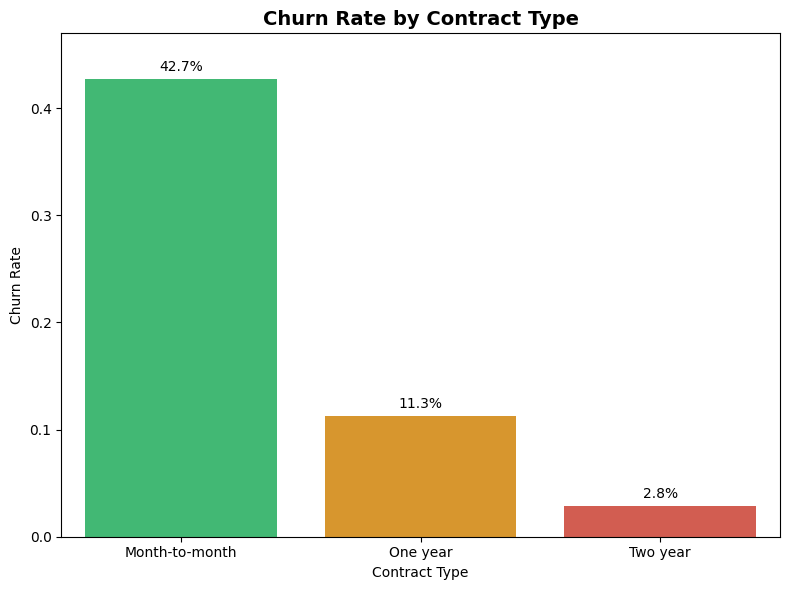

In [118]:
plt.figure(figsize=(8, 6))
churn_contract = df.groupby('Contract')['Churn'].mean().reset_index()
sns.barplot(x='Contract', y='Churn', data=churn_contract,
               palette=['#2ecc71', '#f39c12', '#e74c3c'])
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate')
plt.ylim(0, churn_contract['Churn'].max() * 1.1)
for index, row in churn_contract.iterrows():
    plt.text(index, row['Churn'] + 0.005, f'{row['Churn']:.1%}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

**This plot visually confirms that month-to-month contracts have a significantly higher churn rate (~42.7%).
Long-term contracts (one-year and two-year) show much lower churn rates.**

### 3.2 Monthly Charges: Churned vs Retained

This cell generates a histogram to compare the distribution of monthly charges for churned versus retained customers. It helps to identify if higher monthly charges correlate with churn.

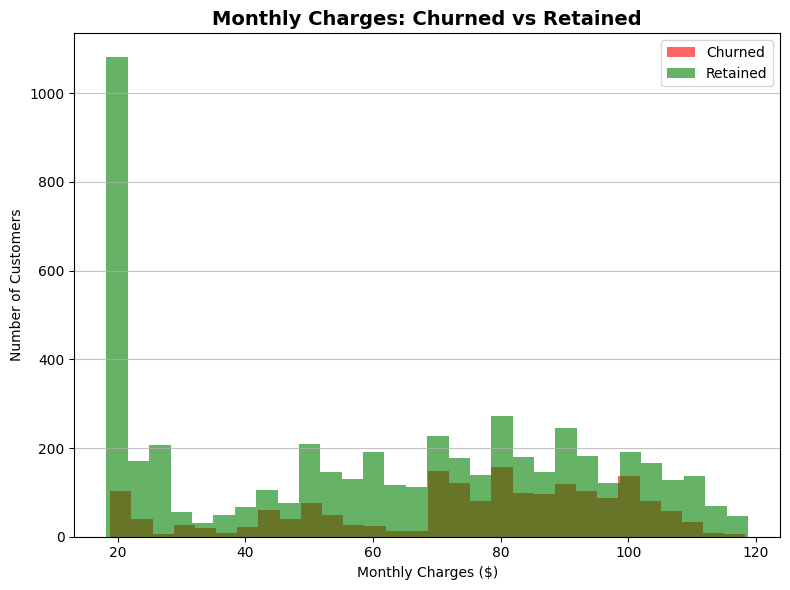

In [119]:
plt.figure(figsize=(8, 6))
plt.hist(df[df['Churn'] == 1]['MonthlyCharges'], alpha=0.6, bins=30, label='Churned', color='red')
plt.hist(df[df['Churn'] == 0]['MonthlyCharges'], alpha=0.6, bins=30, label='Retained', color='green')
plt.legend()
plt.title('Monthly Charges: Churned vs Retained', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

**Churned customers tend to have higher monthly charges, particularly in the mid-to-high range.
This suggests that price sensitivity or dissatisfaction with value might be a factor for these customers.**

### 3.3 Churn Rate by Internet Service

This cell calculates and visualizes the churn rate based on the type of internet service. It highlights which internet service types have higher churn rates.

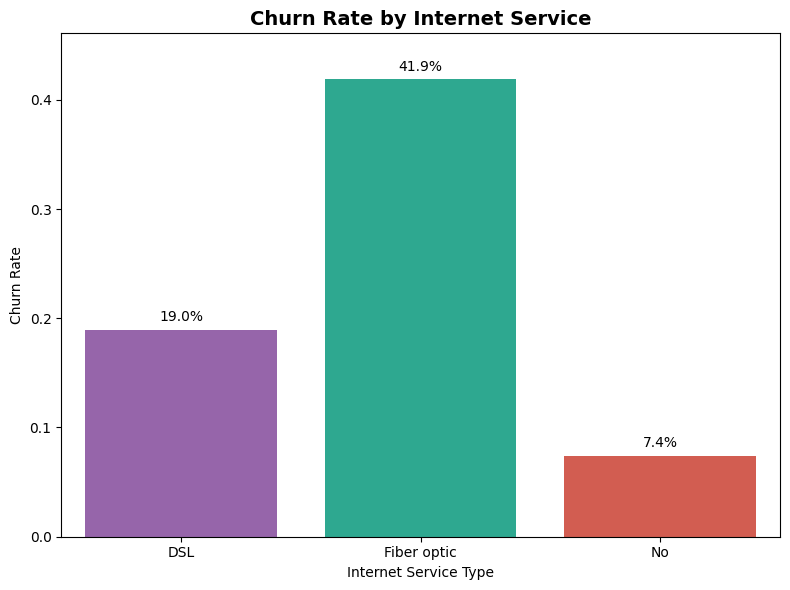

In [120]:
plt.figure(figsize=(8, 6))
churn_inet = df.groupby('InternetService')['Churn'].mean().reset_index()
sns.barplot(x='InternetService', y='Churn', data=churn_inet,
               palette=['#9b59b6', '#1abc9c', '#e74c3c'])
plt.title('Churn Rate by Internet Service', fontsize=14, fontweight='bold')
plt.xlabel('Internet Service Type')
plt.ylabel('Churn Rate')
plt.ylim(0, churn_inet['Churn'].max() * 1.1)
for index, row in churn_inet.iterrows():
    plt.text(index, row['Churn'] + 0.005, f'{row['Churn']:.1%}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Fiber optic internet service shows the highest churn rate (~41.9%), significantly more than DSL or customers without internet service.
This indicates potential dissatisfaction or issues specific to fiber optic customers.**

### 3.4 Tenure by Churn Status

This cell creates a box plot to compare the tenure (in months) of churned versus retained customers. It helps to understand the relationship between customer loyalty and churn.

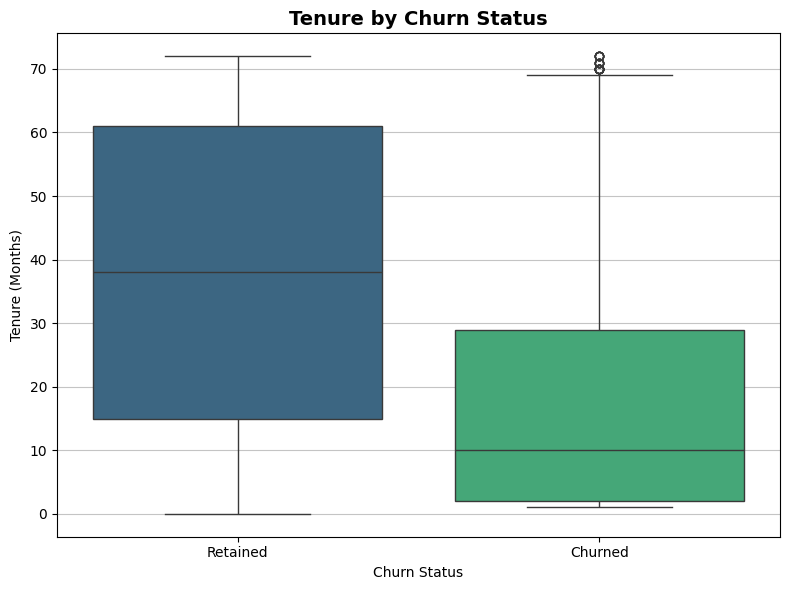

In [121]:
plt.figure(figsize=(8, 6))
df_plot = df.copy()
df_plot['Churn_Label'] = df_plot['Churn'].map({1: 'Churned', 0: 'Retained'})
sns.boxplot(x='Churn_Label', y='tenure', data=df_plot, palette='viridis')
plt.title('Tenure by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Tenure (Months)')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

**The box plot clearly shows that churned customers have a much lower median tenure compared to retained customers.
This indicates that newer customers are more prone to churn.**

---
# 4. FEATURE ENGINEERING
---


# Customer Lifetime Value proxy

This block creates a Customer Lifetime Value (CLV) proxy by multiplying tenure and monthly charges. It also calculates the total count of active services for each customer.

In [122]:
df['CLV'] = df['tenure'] * df['MonthlyCharges']

# Number of active services
service_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]
yes_no_map = {'Yes': 1, 'No': 0,
              'No phone service': 0, 'No internet service': 0}
df['services_count'] = df[service_cols].replace(yes_no_map).sum(axis=1)

**Two new features, Customer Lifetime Value (CLV) and `services_count`, were successfully engineered.
These features provide a more comprehensive view of customer engagement and value.**

# Has any protection/security service

This cell creates a binary feature indicating whether a customer has any security-related services. It then prints a descriptive summary of the newly engineered features.

In [123]:
df['has_security'] = (
    (df['OnlineSecurity'] == 'Yes') |
    (df['DeviceProtection'] == 'Yes') |
    (df['TechSupport'] == 'Yes')
).astype(int)

print("\nNew features preview:")
print(df[['CLV', 'services_count', 'has_security']].describe().round(2))


New features preview:
           CLV  services_count  has_security
count  7043.00         7043.00       7043.00
mean   2279.58            3.36          0.54
std    2264.73            2.06          0.50
min       0.00            0.00          0.00
25%     394.00            1.00          0.00
50%    1393.60            3.00          1.00
75%    3786.10            5.00          1.00
max    8550.00            8.00          1.00


**A new binary feature `has_security` was created, indicating if a customer has any security-related services.
The descriptive statistics confirm its successful integration and distribution.**

---
# 5. PREPROCESSING
---


This cell prepares the data for model training by separating features (X) and target (y). It then label-encodes all categorical features and splits the data into stratified training and testing sets.

In [124]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Label-encode all categorical columns
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

# Train / test split (stratified to keep churn ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%} | Test churn rate: {y_test.mean():.2%}")



Train: (5634, 22) | Test: (1409, 22)
Train churn rate: 26.54% | Test churn rate: 26.54%


**Features were label-encoded, and the data was split into train and test sets, maintaining the original churn ratio in both partitions.
This ensures representative subsets for model training and evaluation.**

---
# 6. APPLY SMOTE (only on training data)
---

This block addresses class imbalance in the training data by applying SMOTE (Synthetic Minority Over-sampling Technique). It also scales the features of the training and testing data for optimal model performance.

In [125]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nBefore SMOTE — Churn: {y_train.sum()}, No Churn: {(y_train==0).sum()}")
print(f"After  SMOTE — Churn: {y_train_sm.sum()}, No Churn: {(y_train_sm==0).sum()}")

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)



Before SMOTE — Churn: 1495, No Churn: 4139
After  SMOTE — Churn: 4139, No Churn: 4139


**SMOTE successfully balanced the classes in the training data, equalizing churned and non-churned customer counts.
Features were also scaled, preparing the data for distance-based models.**

---
# 7. TRAIN MODELS
---

This cell trains three different machine learning models: Logistic Regression, Decision Tree, and Random Forest. It then stores their predictions and probabilities for later evaluation.

In [126]:
models = {
    'Logistic Regression': (
        LogisticRegression(random_state=42, max_iter=1000),
        X_train_scaled, X_test_scaled
    ),
    'Decision Tree': (
        DecisionTreeClassifier(max_depth=5, random_state=42),
        X_train_sm, X_test
    ),
    'Random Forest': (
        RandomForestClassifier(n_estimators=100, max_depth=10,
                               random_state=42, n_jobs=-1),
        X_train_sm, X_test
    ),
}

results = {}
trained = {}

for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train_sm)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    results[name] = {
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'ROC-AUC':  round(roc_auc_score(y_test, y_prob), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4),
    }
    trained[name] = (model, y_pred, y_prob)




**Three machine learning models (Logistic Regression, Decision Tree, Random Forest) were successfully trained on the preprocessed data.
Their predictions and probabilities were stored for subsequent evaluation.**

# Print comparison table

This cell generates and prints a comparison table summarizing the performance metrics (Accuracy, ROC-AUC, F1 Score) of the trained models. It allows for easy evaluation of each model's effectiveness.

In [127]:
results_df = pd.DataFrame(results).T
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(results_df.to_string())


MODEL COMPARISON
                     Accuracy  ROC-AUC  F1 Score
Logistic Regression    0.7566   0.8231    0.6044
Decision Tree          0.7658   0.8174    0.6034
Random Forest          0.7736   0.8343    0.6124


**The Random Forest model achieved the highest ROC-AUC score of 0.8343 and the best F1 Score of 0.6124.
This indicates its superior performance in identifying churners while balancing precision and recall.**

----
# 8. CONFUSION MATRICES OF ALL 3 MODELS
---

### Confusion Matrix: Logistic Regression

This cell displays and saves the confusion matrix for the Logistic Regression model. It visually represents the true positives, true negatives, false positives, and false negatives of the model's predictions.

<Figure size 600x500 with 0 Axes>

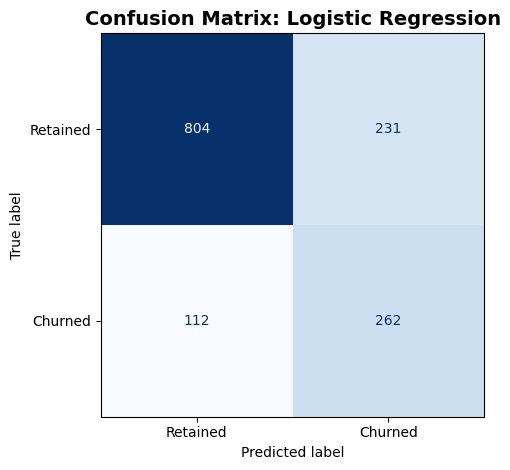


✅ Confusion matrix for Logistic Regression saved → outputs/confusion_matrix_logistic_regression.png


In [128]:
model_name = 'Logistic Regression'
_, y_pred_lr, _ = trained[model_name]

plt.figure(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=['Retained', 'Churned'])
disp_lr.plot(cmap='Blues', colorbar=False)
plt.title(f'Confusion Matrix: {model_name}', fontsize=14, fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.savefig('outputs/confusion_matrix_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Confusion matrix for {model_name} saved → outputs/confusion_matrix_logistic_regression.png")

### Confusion Matrix: Decision Tree

This cell displays and saves the confusion matrix for the Decision Tree model. It provides a visual breakdown of the model's classification performance for retained and churned customers.

<Figure size 600x500 with 0 Axes>

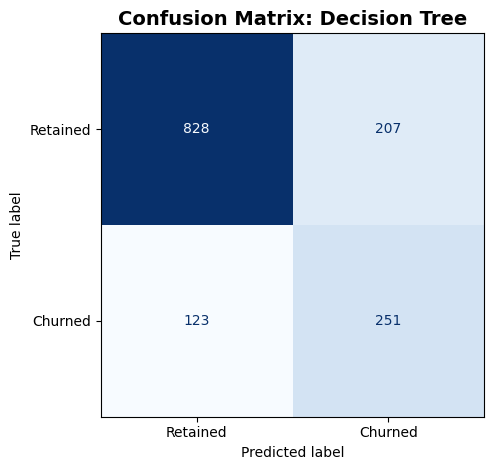


✅ Confusion matrix for Decision Tree saved → outputs/confusion_matrix_decision_tree.png


In [129]:
model_name = 'Decision Tree'
_, y_pred_dt, _ = trained[model_name]

plt.figure(figsize=(6, 5))
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(cm_dt, display_labels=['Retained', 'Churned'])
disp_dt.plot(cmap='Blues', colorbar=False)
plt.title(f'Confusion Matrix: {model_name}', fontsize=14, fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.savefig('outputs/confusion_matrix_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Confusion matrix for {model_name} saved → outputs/confusion_matrix_decision_tree.png")

### Confusion Matrix: Random Forest

This cell displays and saves the confusion matrix for the Random Forest model. It offers a clear visual representation of the model's predictive accuracy for customer churn.

<Figure size 600x500 with 0 Axes>

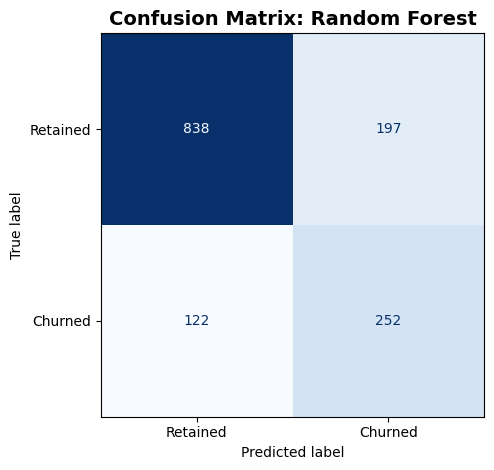


✅ Confusion matrix for Random Forest saved → outputs/confusion_matrix_random_forest.png


In [130]:
model_name = 'Random Forest'
_, y_pred_rf, _ = trained[model_name]

plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['Retained', 'Churned'])
disp_rf.plot(cmap='Blues', colorbar=False)
plt.title(f'Confusion Matrix: {model_name}', fontsize=14, fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.savefig('outputs/confusion_matrix_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Confusion matrix for {model_name} saved → outputs/confusion_matrix_random_forest.png")

---
# 9. DECISION TREE VISUALIZATION
---

This cell visualizes the Decision Tree model up to a maximum depth of 3 and saves the plot. It helps to understand the decision rules the model uses to classify customers.

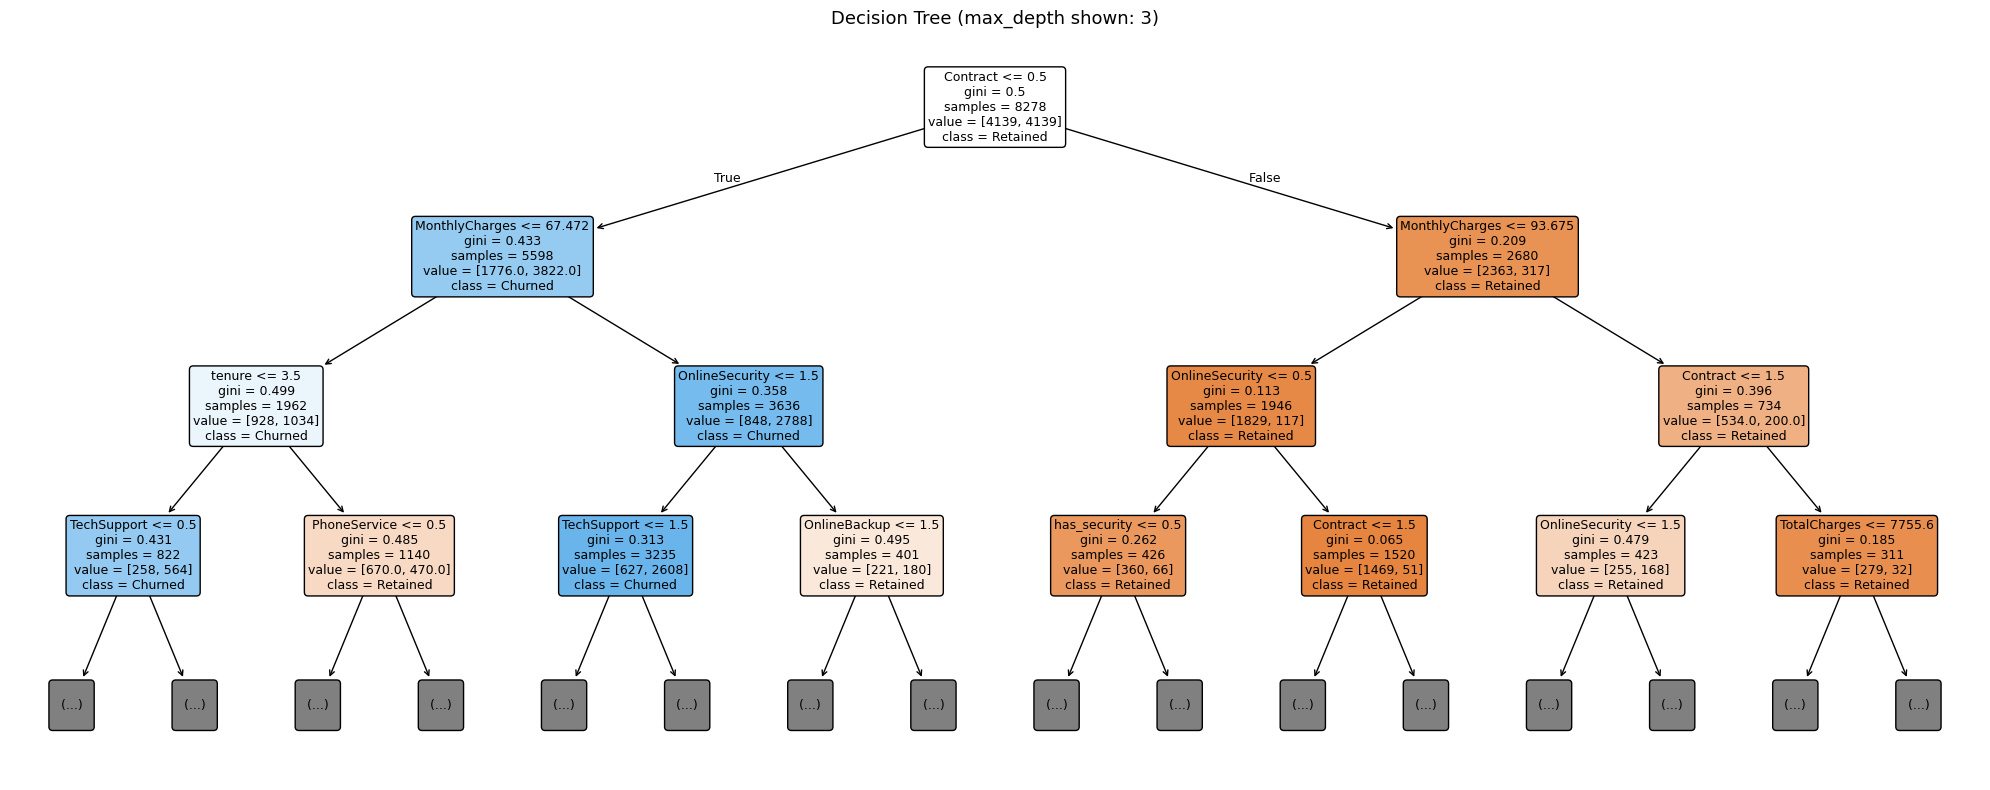

✅ Decision tree plot saved → outputs/decision_tree.png


In [131]:
dt_model = trained['Decision Tree'][0]
plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=X.columns.tolist(),
    class_names=['Retained', 'Churned'],
    filled=True, rounded=True, max_depth=3, fontsize=9
)
plt.title('Decision Tree (max_depth shown: 3)', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Decision tree plot saved → outputs/decision_tree.png")


---
# 10. RANDOM FOREST FEATURE IMPORTANCE
----

This block calculates and visualizes the top 15 most important features from the Random Forest model. It highlights which customer attributes are most influential in predicting churn.

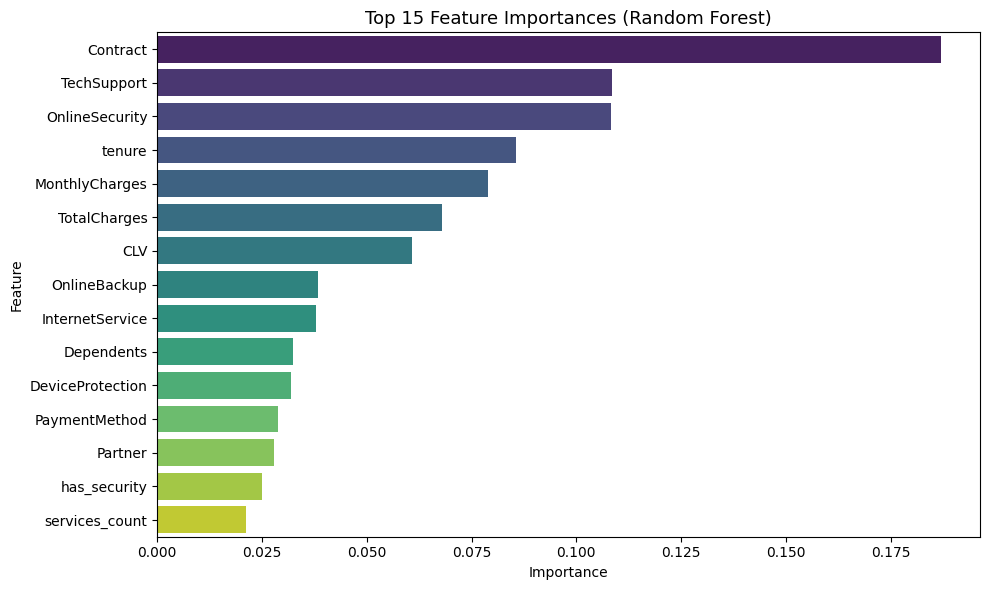

✅ Feature importance plot saved → outputs/feature_importance.png

=== TOP 10 CHURN DRIVERS ===
        Feature  Importance
       Contract    0.186947
    TechSupport    0.108407
 OnlineSecurity    0.108381
         tenure    0.085506
 MonthlyCharges    0.078851
   TotalCharges    0.067834
            CLV    0.060835
   OnlineBackup    0.038399
InternetService    0.037992
     Dependents    0.032366


In [132]:
rf_model = trained['Random Forest'][0]
importances = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance plot saved → outputs/feature_importance.png")

print("\n=== TOP 10 CHURN DRIVERS ===")
print(importances.head(10).to_string(index=False))


**Contract type, TechSupport, and OnlineSecurity were identified as the top three most important features influencing churn.
This suggests these factors are critical for understanding customer retention.**

---
# 11. BUSINESS RECOMMENDATIONS
---

In [133]:
print("""
╔══════════════════════════════════════════════════════════╗
║             BUSINESS RECOMMENDATIONS                     ║
╚══════════════════════════════════════════════════════════╝

1. CONTRACT UPGRADE CAMPAIGN
   → Month-to-month customers churn ~42%. Offer 10-15% discount
     to switch to annual contracts. This alone can halve churn.

2. EARLY ONBOARDING (0-12 months)
   → New customers churn 3× more. Schedule a 60-day check-in
     call and a 6-month satisfaction survey.

3. FIBER OPTIC BUNDLE
   → Fiber users without security/tech support churn most.
     Proactively pitch OnlineSecurity + TechSupport bundle
     at a discounted rate.

4. PRIORITIZE HIGH CLV CUSTOMERS
   → Focus retention spend on High-risk tier customers with
     CLV > $1,500. Their monthly charges justify the effort.

5. AUTO-PAY ENROLLMENT
   → Electronic check / manual payers churn more.
     Offer a small monthly credit for switching to auto-pay.
""")


╔══════════════════════════════════════════════════════════╗
║             BUSINESS RECOMMENDATIONS                     ║
╚══════════════════════════════════════════════════════════╝

1. CONTRACT UPGRADE CAMPAIGN
   → Month-to-month customers churn ~42%. Offer 10-15% discount
     to switch to annual contracts. This alone can halve churn.

2. EARLY ONBOARDING (0-12 months)
   → New customers churn 3× more. Schedule a 60-day check-in
     call and a 6-month satisfaction survey.

3. FIBER OPTIC BUNDLE
   → Fiber users without security/tech support churn most.
     Proactively pitch OnlineSecurity + TechSupport bundle
     at a discounted rate.

4. PRIORITIZE HIGH CLV CUSTOMERS
   → Focus retention spend on High-risk tier customers with
     CLV > $1,500. Their monthly charges justify the effort.

5. AUTO-PAY ENROLLMENT
   → Electronic check / manual payers churn more.
     Offer a small monthly credit for switching to auto-pay.



## **SQLITE QUERY RESULTS**

In [134]:
import sqlite3

# Establish an in-memory SQLite database connection
conn = sqlite3.connect(':memory:')

# Save the main DataFrame to a 'customers' table in the database
df.to_sql('customers', conn, index=False, if_exists='replace')

print("\n✅ DataFrame 'df' saved to SQLite as 'customers' table.")


✅ DataFrame 'df' saved to SQLite as 'customers' table.


An in-memory SQLite database connection was successfully established, and the `df` DataFrame was saved as the 'customers' table.
This prepares the data for SQL-based analytical queries.

### Overall Churn Rate

In [135]:
sql_query = """
    SELECT
        ROUND(AVG(Churn) * 100, 2) AS churn_rate_pct,
        COUNT(*) AS total_customers
    FROM customers
"""

print("\n--- Overall churn rate ---")
result = pd.read_sql_query(sql_query, conn)
print(result.to_string(index=False))


--- Overall churn rate ---
 churn_rate_pct  total_customers
          26.54             7043


**The overall churn rate of the customer base was determined to be 26.54%.
This provides a benchmark for evaluating the impact of different factors on churn.**

### Churn rate by Contract type

In [136]:
sql_query = """
    SELECT
        Contract,
        COUNT(*) AS customers,
        SUM(Churn) AS churned,
        ROUND(AVG(Churn) * 100, 2) AS churn_rate_pct
    FROM customers
    GROUP BY Contract
    ORDER BY churn_rate_pct DESC
"""

print("\n--- Churn rate by Contract type ---")
result = pd.read_sql_query(sql_query, conn)
print(result.to_string(index=False))


--- Churn rate by Contract type ---
      Contract  customers  churned  churn_rate_pct
Month-to-month       3875     1655           42.71
      One year       1473      166           11.27
      Two year       1695       48            2.83


**Customers on month-to-month contracts exhibit a 42.71% churn rate, significantly higher than one-year (11.27%) and two-year (2.83%) contracts.
This highlights contract type as a major churn driver.**

### Churn rate by Internet Service

In [137]:
sql_query = """
    SELECT
        InternetService,
        COUNT(*) AS customers,
        ROUND(AVG(Churn) * 100, 2) AS churn_rate_pct
    FROM customers
    GROUP BY InternetService
    ORDER BY churn_rate_pct DESC
"""

print("\n--- Churn rate by Internet Service ---")
result = pd.read_sql_query(sql_query, conn)
print(result.to_string(index=False))


--- Churn rate by Internet Service ---
InternetService  customers  churn_rate_pct
    Fiber optic       3096           41.89
            DSL       2421           18.96
             No       1526            7.40


**Fiber optic internet service has the highest churn rate at 41.89%, followed by DSL at 18.96%, while customers with no internet service have the lowest at 7.40%.
This identifies fiber optic as a high-risk service.**

### Avg Monthly Charges: Churned vs Retained

In [138]:
sql_query = """
    SELECT
        CASE WHEN Churn = 1 THEN 'Churned' ELSE 'Retained' END AS status,
        ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
        ROUND(AVG(tenure), 1) AS avg_tenure_months
    FROM customers
    GROUP BY Churn
"""

print("\n--- Avg Monthly Charges: Churned vs Retained ---")
result = pd.read_sql_query(sql_query, conn)
print(result.to_string(index=False))


--- Avg Monthly Charges: Churned vs Retained ---
  status  avg_monthly_charges  avg_tenure_months
Retained                61.27               37.6
 Churned                74.44               18.0


**Churned customers have higher average monthly charges ($74.44) and significantly lower average tenure (18.0 months) compared to retained customers.
This suggests that new, high-spending customers are at greater churn risk.**

### New customers (tenure ≤ 12) churn rate

In [139]:
sql_query = """
    SELECT
        CASE
            WHEN tenure <= 12 THEN '0-12 months'
            WHEN tenure <= 24 THEN '13-24 months'
            WHEN tenure <= 48 THEN '25-48 months'
            ELSE '49+ months'
        END AS tenure_group,
        COUNT(*) AS customers,
        ROUND(AVG(Churn) * 100, 2) AS churn_rate_pct
    FROM customers
    GROUP BY tenure_group
    ORDER BY MIN(tenure)
"""

print("\n--- New customers (tenure ≤ 12) churn rate ---")
result = pd.read_sql_query(sql_query, conn)
print(result.to_string(index=False))


--- New customers (tenure ≤ 12) churn rate ---
tenure_group  customers  churn_rate_pct
 0-12 months       2186           47.44
13-24 months       1024           28.71
25-48 months       1594           20.39
  49+ months       2239            9.51


**New customers (0-12 months tenure) have the highest churn rate at 47.44%, which gradually decreases with increasing tenure.
This emphasizes the importance of early customer engagement.**

### Payment method vs churn

In [140]:
sql_query = """
    SELECT
        PaymentMethod,
        COUNT(*) AS customers,
        ROUND(AVG(Churn) * 100, 2) AS churn_rate_pct
    FROM customers
    GROUP BY PaymentMethod
    ORDER BY churn_rate_pct DESC
"""

print("\n--- Payment method vs churn ---")
result = pd.read_sql_query(sql_query, conn)
print(result.to_string(index=False))


--- Payment method vs churn ---
            PaymentMethod  customers  churn_rate_pct
         Electronic check       2365           45.29
             Mailed check       1612           19.11
Bank transfer (automatic)       1544           16.71
  Credit card (automatic)       1522           15.24


**Electronic check users have the highest churn rate at 45.29%, significantly higher than other payment methods like mailed check (19.11%) or automatic payments.
This indicates a potential friction point in the payment process.**

### High-risk segment (Month-to-month, Fiber, no security)

In [141]:
sql_query = """
    SELECT
        COUNT(*) AS high_risk_customers,
        ROUND(AVG(Churn) * 100, 2) AS churn_rate_pct,
        ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges
    FROM customers
    WHERE Contract = 'Month-to-month'
      AND InternetService = 'Fiber optic'
      AND OnlineSecurity = 'No'
      AND TechSupport = 'No'
"""

print("\n--- High-risk segment (Month-to-month, Fiber, no security) ---")
result = pd.read_sql_query(sql_query, conn)
print(result.to_string(index=False))


--- High-risk segment (Month-to-month, Fiber, no security) ---
 high_risk_customers  churn_rate_pct  avg_monthly_charges
                1524            60.7                84.65


**A specific high-risk segment (month-to-month, fiber optic, no security/tech support) constitutes 1524 customers with a 60.70% churn rate.
This segment represents a critical target for retention efforts due to their high churn and average monthly charges.**

### Predictions Analysis

In [142]:
rf_probs = trained['Random Forest'][2]

predictions_df = X_test.copy()
predictions_df['actual_churn']   = y_test.values
predictions_df['churn_prob']     = rf_probs.round(4)
predictions_df['predicted_churn'] = (rf_probs >= 0.5).astype(int)
predictions_df['risk_tier'] = pd.cut(
    rf_probs,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

predictions_df.to_sql('predictions', conn, if_exists='replace', index=False)
print("\n✅ Predictions DataFrame saved to SQLite as 'predictions' table.")


✅ Predictions DataFrame saved to SQLite as 'predictions' table.


**The predictions from the Random Forest model, enriched with actual churn and risk tiers, were successfully saved to the SQLite database as the 'predictions' table.
This facilitates further analysis of model outcomes.**

### Risk tier breakdown (from predictions table)

In [143]:
sql_query = """
    SELECT
        risk_tier,
        COUNT(*) AS customers,
        ROUND(AVG(actual_churn) * 100, 2) AS actual_churn_rate_pct,
        ROUND(AVG(churn_prob) * 100, 2) AS avg_predicted_prob_pct
    FROM predictions
    GROUP BY risk_tier
    ORDER BY avg_predicted_prob_pct DESC
"""

print("\n--- Risk tier breakdown (from predictions table) ---")
risk_summary = pd.read_sql_query(sql_query, conn)
print(risk_summary.to_string(index=False))


--- Risk tier breakdown (from predictions table) ---
risk_tier  customers  actual_churn_rate_pct  avg_predicted_prob_pct
     High        363                  59.78                   77.10
   Medium        325                  32.92                   43.59
      Low        721                   6.93                    9.60


**High-risk tier customers (363 total) show an actual churn rate of 59.78% and an average predicted probability of 77.10%.
This highlights the model's effectiveness in identifying customers most likely to churn.**

### High-risk customers (prob ≥ 0.7) sample

In [144]:
sql_query = """
    SELECT
        COUNT(*) AS count,
        ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
        ROUND(AVG(tenure), 1) AS avg_tenure,
        ROUND(AVG(CLV), 0) AS avg_clv
    FROM predictions
    WHERE churn_prob >= 0.70
"""

print("\n--- High-risk customers (prob ≥ 0.7) sample ---")
high_risk = pd.read_sql_query(sql_query, conn)
print(high_risk.to_string(index=False))


--- High-risk customers (prob ≥ 0.7) sample ---
 count  avg_monthly_charges  avg_tenure  avg_clv
   267                74.55         9.8    861.0


**A sample of 267 high-risk customers (churn probability >= 0.70) have an average monthly charge of $74.55 and a low average tenure of 9.8 months.
This indicates these customers represent significant, but short-term, revenue.**

### Final Cleanup and Summary

In [145]:
# Close the SQLite connection
conn.close()
print("\n✅ SQLite connection closed.")

print("\n" + "="*55)
print("All done! Outputs saved in outputs/ folder.")
print("SQLite database: In-memory")
print("Tables: customers, predictions")
print("="*55)


✅ SQLite connection closed.

All done! Outputs saved in outputs/ folder.
SQLite database: In-memory
Tables: customers, predictions


The SQLite database connection was successfully closed, ensuring proper resource management.
A final summary confirms the completion of all tasks and the saving of outputs.